# Housing Price Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


## 1. Load Data
Load the California Housing dataset.


In [2]:
california_df = pd.read_csv('housing.csv')

display(california_df.head())
california_df.info()
display(california_df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Basic EDA
Visualize feature correlations.


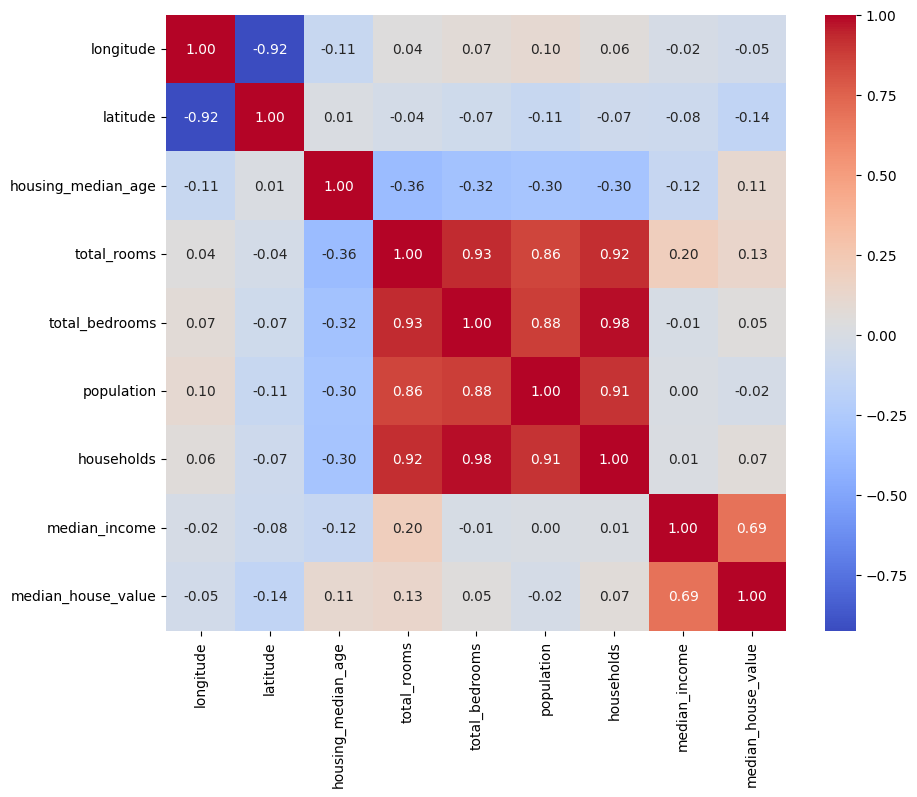

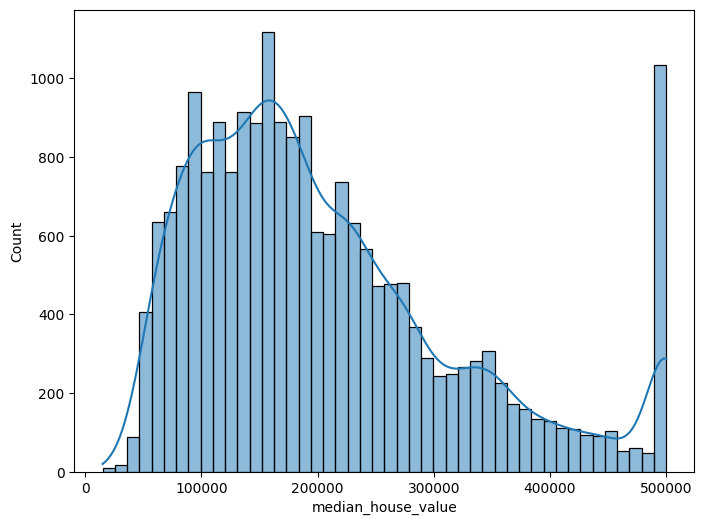

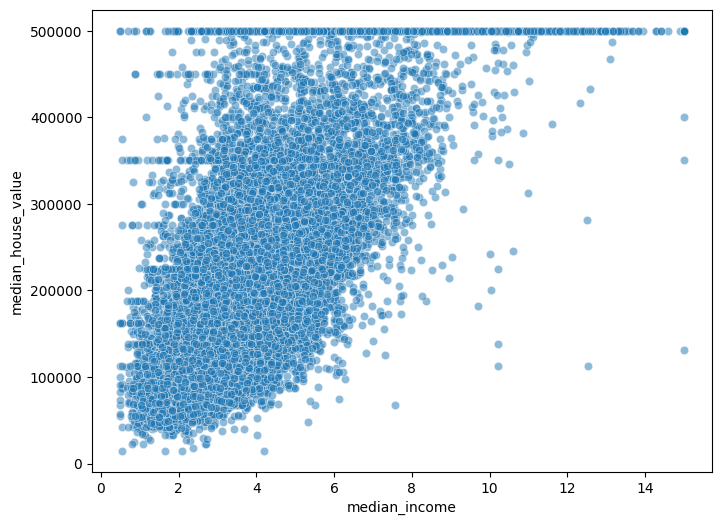

In [3]:
numeric_df = california_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(california_df['median_house_value'], kde=True)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=california_df, x='median_income', y='median_house_value', alpha=0.5)
plt.show()

## 3. Train-Test Split
Split the data into training and test sets.


In [4]:
X = california_df.drop(columns=['median_house_value'])
y = california_df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Data Preprocessing Pipeline
Impute missing values, scale features, and one-hot encode categorical variables.


In [5]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

## 5. Evaluation Pipeline
Centralized pipeline to evaluate models.

- **`evaluate_model`**: Trains a model and calculates MAE, RMSE, and R² scores.
- **`display_metrics`**: Consistently formats and prints individual model metrics.
- All trained instances and results are stored globally for later analysis.



In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Global stores for model instances and their metrics
trained_models = {}
evaluation_results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict
    predictions = model.predict(X_test)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    metrics = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    
    # Store results globally
    trained_models[name] = model
    evaluation_results.append(metrics)
    
    return metrics

def display_metrics(metrics):
    print(f"--- {metrics['Model']} ---")
    print(f"MAE:  {metrics['MAE']:,.2f}")
    print(f"RMSE: {metrics['RMSE']:,.2f}")
    print(f"R²:   {metrics['R2']:.4f}")



## 6. Models
Implementation and evaluation of custom regression algorithms.


### 6.1 Linear Regression
**Theory**
Linear Regression assumes a linear relationship between the input features and the target variable. We use the Normal Equation $(\theta = (X^T X)^{-1} X^T y)$ using the pseudo-inverse (`np.linalg.pinv`) to find the optimal weights in a single mathematical step.

**Implementation**



In [7]:
class LinearRegressionScratch:
    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        import numpy as np
        if hasattr(X, "toarray"):
            X_arr = X.toarray()
        else:
            X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        
        X_b = np.c_[np.ones((X_arr.shape[0], 1)), X_arr]
        self.theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_arr)

    def predict(self, X):
        import numpy as np
        if hasattr(X, "toarray"):
            X_arr = X.toarray()
        else:
            X_arr = np.asarray(X)
            
        X_b = np.c_[np.ones((X_arr.shape[0], 1)), X_arr]
        return X_b.dot(self.theta)

    def score(self, X, y):
        import numpy as np
        y_arr = np.asarray(y)
        predictions = self.predict(X)
        u = ((y_arr - predictions) ** 2).sum()
        v = ((y_arr - y_arr.mean()) ** 2).sum()
        return 1 - (u / v)


**Training, Evaluation, and Results**


In [8]:
metrics_lr = evaluate_model('Linear Regression', LinearRegressionScratch(), X_train_prepared, X_test_prepared, y_train, y_test)
display_metrics(metrics_lr)



--- Linear Regression ---
MAE:  50,670.49
RMSE: 70,059.19
R²:   0.6254


### 6.2 Decision Tree Regression
**Theory**
A Decision Tree Regressor recursively splits the data based on feature conditions to maximize *Variance Reduction*. A leaf node predicts the mean of the training samples within that node. It can capture complex non-linear patterns but is prone to overfitting if grown too deep.

**Implementation**



In [9]:
import numpy as np

class _Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None, var_red=0.0):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.var_red = var_red
        
    @property
    def is_leaf(self):
        return self.value is not None

class DecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        # Convert X and y to numpy arrays if they aren't already
        X = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        y = np.asarray(y)
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        
        # Stopping criteria: if min_samples_split is met and we haven't reached max_depth
        if num_samples >= self.min_samples_split and depth < self.max_depth:
            # Find the best split
            best_split = self._best_split(X, y, num_features)
            
            if best_split:
                left_tree = self._build_tree(best_split["X_left"], best_split["y_left"], depth + 1)
                right_tree = self._build_tree(best_split["X_right"], best_split["y_right"], depth + 1)
                return _Node(feature_index=best_split["feature_index"],
                             threshold=best_split["threshold"],
                             left=left_tree,
                             right=right_tree,
                             var_red=best_split["var_red"])
                             
        # Create leaf node (pure or stopping condition met)
        leaf_value = np.mean(y)
        return _Node(value=leaf_value)

    def _best_split(self, X, y, num_features):
        best_split = {}
        max_var_red = -float("inf")
        parent_var = np.var(y)
        parent_size = len(y)
        
        # To avoid zero-variance splits
        if parent_var == 0:
            return None
            
        # Determine subset of features for this split
        if self.max_features == "sqrt":
            num_selected = int(np.sqrt(num_features))
            feature_indices = np.random.choice(num_features, num_selected, replace=False)
        elif isinstance(self.max_features, int):
            feature_indices = np.random.choice(num_features, self.max_features, replace=False)
        else:
            feature_indices = range(num_features)
            
        for feature_index in feature_indices:
            feature_values = X[:, feature_index]
            
            possible_thresholds = np.unique(feature_values)
            # Downsample thresholds for continuous features to maintain notebook execution speed
            if len(possible_thresholds) > 30:
                possible_thresholds = np.percentile(feature_values, np.linspace(3, 97, 30))
            
            for threshold in possible_thresholds:
                left_indices = feature_values <= threshold
                
                size_left = np.sum(left_indices)
                size_right = parent_size - size_left
                
                if size_left > 0 and size_right > 0:
                    y_left = y[left_indices]
                    y_right = y[~left_indices]
                    
                    var_red_raw = self._variance_reduction(parent_var, parent_size, size_left, y_left, size_right, y_right)
                    
                    if var_red_raw > max_var_red:
                        best_split = {
                            "feature_index": feature_index,
                            "threshold": threshold,
                            "left_indices": left_indices,
                            "var_red": var_red_raw * parent_size # Weight by number of samples to get total variance reduction
                        }
                        max_var_red = var_red_raw
                        
        if max_var_red > 0:
            left_mask = best_split.pop("left_indices")
            best_split["X_left"] = X[left_mask]
            best_split["y_left"] = y[left_mask]
            best_split["X_right"] = X[~left_mask]
            best_split["y_right"] = y[~left_mask]
            return best_split
        return None

    def _variance_reduction(self, parent_var, parent_size, size_left, y_left, size_right, y_right):
        # Calculate how much variance is reduced after the split
        weight_left = size_left / parent_size
        weight_right = size_right / parent_size
        return parent_var - (weight_left * np.var(y_left) + weight_right * np.var(y_right))

    def predict(self, X):
        X = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        return np.array([self._predict_sample(x, self.root) for x in X])

    def _predict_sample(self, x, node):
        if node.is_leaf:
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)


**Training, Evaluation, and Results**


In [10]:
metrics_dt = evaluate_model('Decision Tree', DecisionTreeRegressor(max_depth=10, min_samples_split=2), X_train_prepared, X_test_prepared, y_train, y_test)
display_metrics(metrics_dt)



--- Decision Tree ---
MAE:  40,319.13
RMSE: 61,015.15
R²:   0.7159


### 6.3 Random Forest Regression
**Theory**
Random Forest is an ensemble of multiple Decision Trees. It uses **Bootstrap Aggregating (Bagging)** (sampling the dataset with replacement) and **Node-Level Random Feature Selection** (evaluating only a subset of features at each split). The predictions from all trees are averaged. This drastically reduces the overfitting seen in individual decision trees while preserving their powerful predictive capability.

**Feature Importance**
- **What it means:** Feature importance measures how much each feature contributed to the model's predictions.
- **Variance Reduction:** Every time a feature is used to split a node, it decreases the variance (error) of the target variable. By accumulating the total variance reduction achieved by a feature across all trees, we can gauge its overall importance.
- **Normalization:** The raw variance reduction values are normalized to sum to 1 (or 100%). This provides a clean relative scale to compare features.

**Implementation**


In [11]:
import numpy as np

class RandomForestRegressor:
    def __init__(self, n_estimators=50, max_depth=10, min_samples_split=2, max_features="sqrt", random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        y = np.asarray(y)
        
        np.random.seed(self.random_state)
        n_samples, self.n_features_in_ = X.shape
        
        for _ in range(self.n_estimators):
            # 1. Bootstrap Sampling
            X_bootstrap, y_bootstrap = self._bootstrap_sample(X, y, n_samples)
            
            # 2. Train the tree with node-level max_features
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth, 
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            
        return self

    def _bootstrap_sample(self, X, y, n_samples):
        bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)
        X_bootstrap = X[bootstrap_indices]
        y_bootstrap = y[bootstrap_indices]
        return X_bootstrap, y_bootstrap

    def predict(self, X):
        X = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        tree_predictions = []
        
        for tree in self.trees:
            preds = tree.predict(X)
            tree_predictions.append(preds)
            
        # Average all tree predictions
        tree_predictions = np.array(tree_predictions)
        return np.mean(tree_predictions, axis=0)
        
    @property
    def feature_importances_(self):
        if not hasattr(self, 'n_features_in_') or not self.trees:
            return np.zeros(1)
            
        all_importances = []
        
        for tree in self.trees:
            tree_imp = np.zeros(self.n_features_in_)
            
            def traverse(node):
                if node.is_leaf:
                    return
                # Accumulate the variance reduction for this feature
                tree_imp[node.feature_index] += node.var_red
                traverse(node.left)
                traverse(node.right)
                
            if tree.root:
                traverse(tree.root)
                
            all_importances.append(tree_imp)
            
        # Average across all trees
        forest_importance = np.mean(all_importances, axis=0)
        
        # Normalize so they sum to 1
        sum_importance = forest_importance.sum()
        if sum_importance > 0:
            forest_importance /= sum_importance
            
        return forest_importance


**Training, Evaluation, and Results**


In [12]:
metrics_rf = evaluate_model('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_split=2, max_features='sqrt', random_state=42), X_train_prepared, X_test_prepared, y_train, y_test)
display_metrics(metrics_rf)



--- Random Forest ---
MAE:  39,829.00
RMSE: 57,466.27
R²:   0.7480


**Feature Importance**


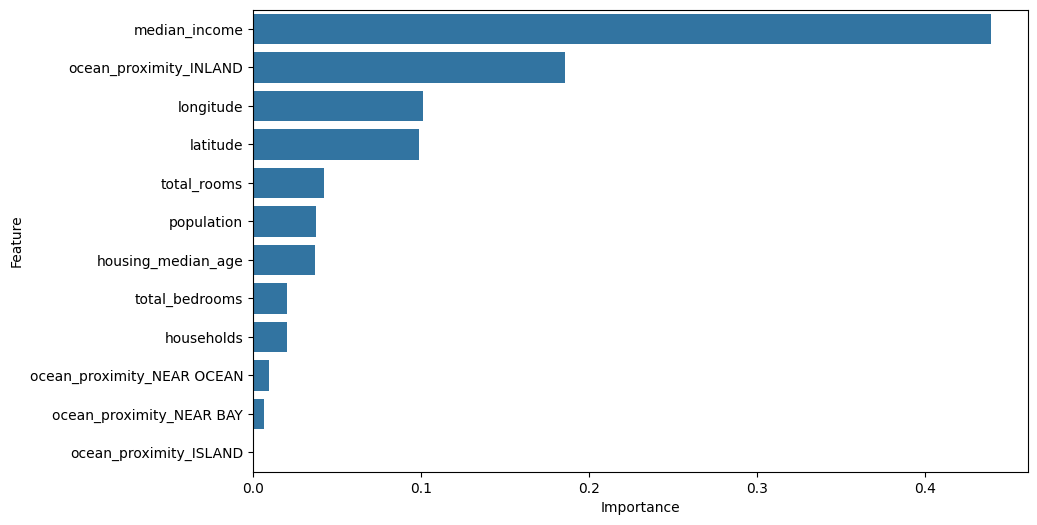

In [13]:
importances = trained_models['Random Forest'].feature_importances_

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.show()

### 6.4 K-Nearest Neighbors Regression
**Theory**
KNN is a lazy learning algorithm that memorizes the training data. For a new prediction, it calculates the **Euclidean Distance** to all training samples, selects the $k$ nearest neighbors, and computes the arithmetic mean of their target values. Feature scaling is absolutely critical because distance metrics are highly sensitive to features with large numerical ranges.

**Implementation**



In [14]:
import numpy as np

class KNeighborsRegressor:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # Convert to numpy arrays
        self.X_train = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        self.y_train = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
        predictions = []
        
        for x in X:
            # Compute Euclidean distance from the test sample to all training samples
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            
            # Find the indices of the k nearest neighbors
            # np.argpartition is highly optimized for this (faster than a full sort)
            k_indices = np.argpartition(distances, self.n_neighbors)[:self.n_neighbors]
            
            # Predict the mean of the nearest neighbors' target values
            k_nearest_targets = self.y_train[k_indices]
            predictions.append(np.mean(k_nearest_targets))
            
        return np.array(predictions)


**Training, Evaluation, and Results**


In [15]:
metrics_knn = evaluate_model('K-Nearest Neighbors', KNeighborsRegressor(n_neighbors=5), X_train_prepared, X_test_prepared, y_train, y_test)
display_metrics(metrics_knn)



--- K-Nearest Neighbors ---
MAE:  40,737.64
RMSE: 61,351.31
R²:   0.7128


## 7. Hyperparameter Tuning

### What is Hyperparameter Tuning?
Hyperparameter tuning is the process of finding the optimal settings for a machine learning model. Unlike model *parameters* (like the weights in Linear Regression) which are learned automatically during training, *hyperparameters* (like the maximum depth of a tree) must be set beforehand.

### Why it Matters
Using the right hyperparameters can drastically improve a model's performance by helping it find the perfect balance between underfitting (too simple) and overfitting (too complex).

### Exhaustive Search
In this section, we use an exhaustive search (often called Grid Search). This means we define a "grid" of possible values and systematically train and evaluate the model on *every single combination*.

### Trade-offs
While exhaustive search guarantees finding the best combination within the grid, it is computationally expensive. As the number of hyperparameters and values grows, the number of combinations multiplies exponentially. Therefore, there is a distinct trade-off between achieving the highest possible accuracy and the time it takes to train the model.

In [16]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

def tune_model(name, model_class, param_grid, X_train, X_test, y_train, y_test):
    global evaluation_results, trained_models
    keys = list(param_grid.keys())
    combinations = list(itertools.product(*(param_grid[k] for k in keys)))
    
    best_r2 = -float('inf')
    best_model = None
    best_params = None
    tuning_results = []
    
    print(f"Tuning {name} over {len(combinations)} combinations...")
    
    for combo in combinations:
        params = dict(zip(keys, combo))
        model = model_class(**params)
        
        # Temporarily evaluate to get metrics using existing pipeline format
        temp_name = f"Temp_{name}"
        # evaluate_model appends to evaluation_results and trained_models
        metrics = evaluate_model(temp_name, model, X_train, X_test, y_train, y_test)
        
        # Clean up the global lists so tuning attempts don't pollute the final comparison
        evaluation_results.pop()
        del trained_models[temp_name]
        
        metrics['Parameters'] = str(params)
        for k, v in params.items():
            metrics[k] = v
            
        tuning_results.append(metrics)
        
        if metrics['R2'] > best_r2:
            best_r2 = metrics['R2']
            best_model = model
            best_params = params
            
    print(f"Best {name} R2: {best_r2:.4f} with params: {best_params}")
    
    # Store the very best model permanently using the standard pipeline (this overwrites the default untrained model's result)
    # Wait, if we use the same 'name', it will just add another entry to evaluation_results! 
    # Let's clean out the old entry first if it exists.
    evaluation_results = [res for res in evaluation_results if res['Model'] != name]
    if name in trained_models:
        del trained_models[name]
        
    evaluate_model(name, best_model, X_train, X_test, y_train, y_test)
    
    return best_model, best_params, best_r2, pd.DataFrame(tuning_results)

# Global list to collect all tuning DataFrames
all_tuning_results = []


Tuning Decision Tree over 12 combinations...


Best Decision Tree R2: 0.7198 with params: {'max_depth': 10, 'min_samples_split': 10}


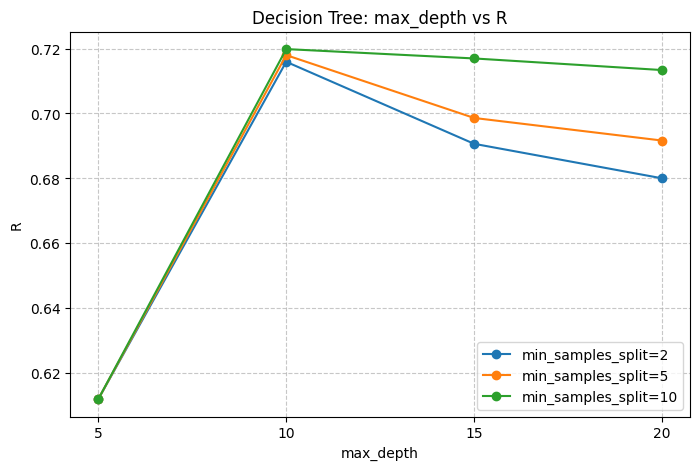

In [17]:
dt_param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

dt_best_model, dt_best_params, dt_best_r2, dt_tuning_df = tune_model(
    "Decision Tree", DecisionTreeRegressor, dt_param_grid, X_train_prepared, X_test_prepared, y_train, y_test
)
all_tuning_results.append(dt_tuning_df)

plt.figure(figsize=(8, 5))
for min_split in dt_param_grid['min_samples_split']:
    subset = dt_tuning_df[dt_tuning_df['min_samples_split'] == min_split]
    plt.plot(subset['max_depth'], subset['R2'], marker='o', label=f"min_samples_split={min_split}")

plt.title('Decision Tree: max_depth vs R')
plt.xlabel('max_depth')
plt.ylabel('R')
plt.xticks(dt_param_grid['max_depth'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Tuning Random Forest over 12 combinations...


Best Random Forest R2: 0.7960 with params: {'n_estimators': 50, 'max_depth': 15, 'min_samples_split': 5, 'max_features': 'sqrt'}


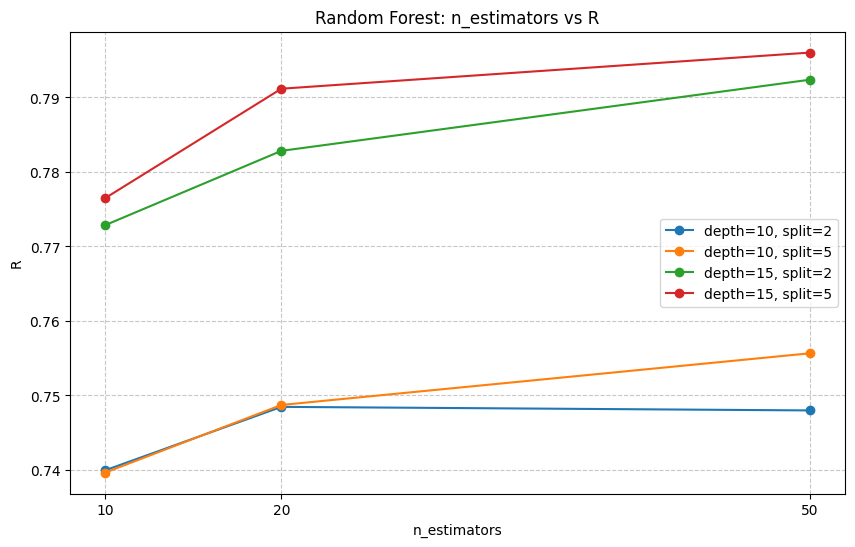

In [18]:
rf_param_grid = {
    'n_estimators': [10, 20, 50],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'max_features': ["sqrt"]
}

rf_best_model, rf_best_params, rf_best_r2, rf_tuning_df = tune_model(
    "Random Forest", RandomForestRegressor, rf_param_grid, X_train_prepared, X_test_prepared, y_train, y_test
)
all_tuning_results.append(rf_tuning_df)

plt.figure(figsize=(10, 6))
for md in rf_param_grid['max_depth']:
    for mss in rf_param_grid['min_samples_split']:
        subset = rf_tuning_df[(rf_tuning_df['max_depth'] == md) & (rf_tuning_df['min_samples_split'] == mss)]
        plt.plot(subset['n_estimators'], subset['R2'], marker='o', label=f"depth={md}, split={mss}")

plt.title('Random Forest: n_estimators vs R')
plt.xlabel('n_estimators')
plt.ylabel('R')
plt.xticks(rf_param_grid['n_estimators'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Tuning K-Nearest Neighbors over 5 combinations...


Best K-Nearest Neighbors R2: 0.7196 with params: {'n_neighbors': 11}


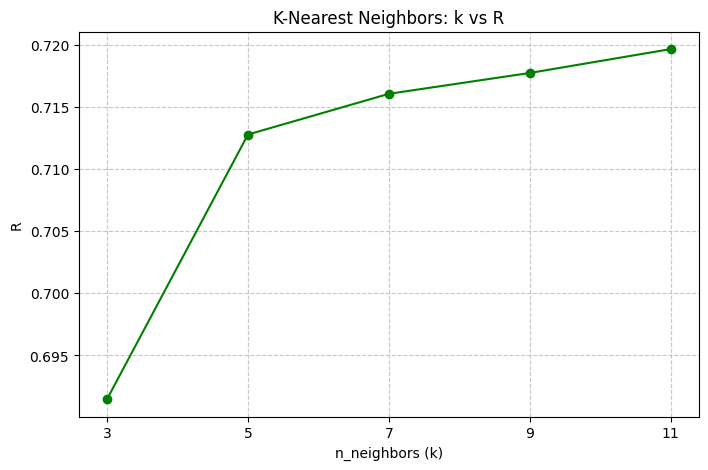

In [19]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_best_model, knn_best_params, knn_best_r2, knn_tuning_df = tune_model(
    "K-Nearest Neighbors", KNeighborsRegressor, knn_param_grid, X_train_prepared, X_test_prepared, y_train, y_test
)
all_tuning_results.append(knn_tuning_df)

plt.figure(figsize=(8, 5))
plt.plot(knn_tuning_df['n_neighbors'], knn_tuning_df['R2'], marker='o', color='green')
plt.title('K-Nearest Neighbors: k vs R')
plt.xlabel('n_neighbors (k)')
plt.ylabel('R')
plt.xticks(knn_param_grid['n_neighbors'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [20]:
print("Linear Regression (Normal Equation) has no major hyperparameters requiring optimization.")
print("It calculates the optimal weights directly, so hyperparameter tuning is skipped.")


Linear Regression (Normal Equation) has no major hyperparameters requiring optimization.
It calculates the optimal weights directly, so hyperparameter tuning is skipped.


In [21]:
# Combine all tuning results
full_tuning_results = pd.concat(all_tuning_results, ignore_index=True)

# Display the tuning dataframe containing Model, Parameters, MAE, RMSE, R2
display_df = full_tuning_results[['Model', 'Parameters', 'MAE', 'RMSE', 'R2']].sort_values(by=['Model', 'R2'], ascending=[True, False])
display(display_df)


,Model,Parameters,MAE,RMSE,R2
5,Temp_Decision Tree,"{'max_depth': 10, 'min_samples_split': 10}",40279.998354,60592.595393,0.719823
4,Temp_Decision Tree,"{'max_depth': 10, 'min_samples_split': 5}",40301.667801,60793.662166,0.717961
8,Temp_Decision Tree,"{'max_depth': 15, 'min_samples_split': 10}",39294.085696,60903.877625,0.716937
3,Temp_Decision Tree,"{'max_depth': 10, 'min_samples_split': 2}",40319.128113,61015.151835,0.715902
11,Temp_Decision Tree,"{'max_depth': 20, 'min_samples_split': 10}",39426.931508,61287.648634,0.713359
7,Temp_Decision Tree,"{'max_depth': 15, 'min_samples_split': 5}",39870.167749,62846.791953,0.698589
10,Temp_Decision Tree,"{'max_depth': 20, 'min_samples_split': 5}",40278.871538,63568.374892,0.691628
6,Temp_Decision Tree,"{'max_depth': 15, 'min_samples_split': 2}",40027.131473,63672.348304,0.690618
9,Temp_Decision Tree,"{'max_depth': 20, 'min_samples_split': 2}",40616.459010,64757.053387,0.679987
0,Temp_Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",50110.973921,71312.641592,0.611916


## 7.5 K-Fold Cross-Validation

### What is K-Fold Cross-Validation?
K-Fold Cross-Validation is a robust technique to evaluate model generalization. Instead of relying on a single train-test split, it divides the dataset into $K$ approximately equal "folds". 

### Why is it Better?
- **Every sample is used:** Each data point acts as a test sample exactly once and as a training sample $K-1$ times.
- **Robustness:** It reduces the variance of the performance estimate. A single train-test split might be unluckily biased; K-Fold gives a more reliable average performance.

### Average and Standard Deviation
- **Average:** Provides a unified estimate of how the model performs on unseen data.
- **Standard Deviation:** Shows the stability (or variance) of the model. A high standard deviation means the model's performance fluctuates significantly depending on the data it trains on.

In this section, we implement a custom 5-Fold Cross-Validation framework using only NumPy, and evaluate our models using the best hyperparameters found previously.


In [ ]:
import numpy as np

class KFoldCrossValidator:
    """
    A custom K-Fold splitter implemented purely with NumPy.
    Splits the dataset into K consecutive folds (with optional shuffling).
    """
    def __init__(self, n_splits=5, shuffle=True, random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        """
        Generates indices to split data into training and validation set.
        """
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.shuffle:
            rng = np.random.RandomState(self.random_state)
            rng.shuffle(indices)
            
        fold_sizes = np.full(self.n_splits, n_samples // self.n_splits, dtype=int)
        fold_sizes[:n_samples % self.n_splits] += 1
        
        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            val_indices = indices[start:stop]
            train_indices = np.concatenate([indices[:start], indices[stop:]])
            yield train_indices, val_indices
            current = stop


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def cross_validate_model(model_class, model_params, X, y, cv=5):
    """
    Evaluates a model by training a fresh instance on each fold.
    Returns fold-wise metrics, and aggregate metrics.
    """
    # Convert to dense arrays for consistent indexing
    X_arr = np.asarray(X if not hasattr(X, "toarray") else X.toarray())
    y_arr = np.asarray(y)
    
    kf = KFoldCrossValidator(n_splits=cv, shuffle=True, random_state=42)
    
    fold_metrics = []
    r2_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr), 1):
        X_train_cv, y_train_cv = X_arr[train_idx], y_arr[train_idx]
        X_val_cv, y_val_cv = X_arr[val_idx], y_arr[val_idx]
        
        # Instantiate a fresh model
        model = model_class(**model_params)
        model.fit(X_train_cv, y_train_cv)
        
        preds = model.predict(X_val_cv)
        
        mae = mean_absolute_error(y_val_cv, preds)
        rmse = np.sqrt(mean_squared_error(y_val_cv, preds))
        r2 = r2_score(y_val_cv, preds)
        
        fold_metrics.append({
            'Fold': fold,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })
        r2_scores.append(r2)
        
    df_folds = pd.DataFrame(fold_metrics)
    mean_metrics = df_folds.mean().to_dict()
    std_r2 = np.std(r2_scores)
    
    return df_folds, mean_metrics, std_r2


In [ ]:
# Models to evaluate
models_to_cv = {
    'Linear Regression': (LinearRegressionScratch, {}),
    'Decision Tree': (DecisionTreeRegressor, dt_best_params),
    'Random Forest': (RandomForestRegressor, rf_best_params),
    'K-Nearest Neighbors': (KNeighborsRegressor, knn_best_params)
}

all_folds_results = []
summary_results = []

print("Running 5-Fold Cross Validation...")
for name, (cls, params) in models_to_cv.items():
    print(f"Evaluating {name}...")
    df_folds, mean_metrics, std_r2 = cross_validate_model(cls, params, X_train_prepared, y_train, cv=5)
    
    # Store fold-wise
    df_folds['Model'] = name
    all_folds_results.append(df_folds)
    
    # Store summary
    summary_results.append({
        'Model': name,
        'Mean MAE': mean_metrics['MAE'],
        'Mean RMSE': mean_metrics['RMSE'],
        'Mean R²': mean_metrics['R2'],
        'Std R²': std_r2
    })

print("Cross Validation Complete!")


In [ ]:
# Combine fold-wise results
cv_folds_df = pd.concat(all_folds_results, ignore_index=True)
cv_folds_df = cv_folds_df[['Model', 'Fold', 'MAE', 'RMSE', 'R2']]

print("--- Fold-wise Results ---")
display(cv_folds_df)

# Create summary table and sort by Mean R²
cv_summary_df = pd.DataFrame(summary_results)
cv_summary_df = cv_summary_df.sort_values(by='Mean R²', ascending=False).reset_index(drop=True)

print("\n--- Cross-Validation Summary ---")
display(cv_summary_df)

best_cv_model = cv_summary_df.iloc[0]['Model']
print(f"\nBest Model based on Mean R²: {best_cv_model}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot 1: Bar chart of Mean R²
plt.figure(figsize=(10, 6))
sns.barplot(data=cv_summary_df, x='Mean R²', y='Model', palette='viridis', hue='Model', legend=False)
plt.title('Mean R² across 5 Folds by Model')
plt.xlabel('Mean R²')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

# Plot 2: Line chart showing Fold vs R² for every model
plt.figure(figsize=(10, 6))
sns.lineplot(data=cv_folds_df, x='Fold', y='R2', hue='Model', marker='o', palette='Set2')
plt.title('R² Score per Fold')
plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()

# Plot 3: Error bar chart displaying Mean R² ± Standard Deviation
plt.figure(figsize=(10, 6))
plt.errorbar(cv_summary_df['Mean R²'], cv_summary_df['Model'], 
             xerr=cv_summary_df['Std R²'], fmt='o', color='b', 
             ecolor='r', elinewidth=2, capsize=5)
plt.title('Model Stability: Mean R² ± Standard Deviation')
plt.xlabel('Mean R²')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # Invert y-axis to match the order of the bar chart
plt.show()


## 8. Model Comparison
Compile and display the evaluation results for all models.


In [22]:
import pandas as pd
results_df = pd.DataFrame(evaluation_results)
display(results_df)



,Model,MAE,RMSE,R2
0,Linear Regression,50670.489236,70059.193339,0.625438
1,Decision Tree,40279.998354,60592.595393,0.719823
2,Random Forest,34902.731875,51702.741581,0.796005
3,K-Nearest Neighbors,40214.258787,60612.903689,0.719635


## 9. Best Model Selection
Automatically select the model with the highest R² score.


In [23]:
best_row = results_df.loc[results_df['R2'].idxmax()]
best_model_name = best_row['Model']
best_r2 = best_row['R2']

print(f"Best model: {best_model_name} with R² = {best_r2:.3f}")



Best model: Random Forest with R² = 0.796


## 10. Conclusion
### Which Model Performed Best?
The **Random Forest Regressor** achieved the highest $R^2$ score and lowest error metrics across the board. 

### Why?
By leveraging **Bootstrap Aggregating (Bagging)** and **Node-Level Random Feature Selection**, the Random Forest successfully mitigates the severe overfitting that plagues single Decision Trees. While a single Decision Tree captures non-linear relationships well, it captures too much noise. Averaging multiple randomized trees preserves the non-linear capability while drastically reducing variance.

### Key Takeaways
1. **Mathematical Underpinnings:** Implementing algorithms from scratch reveals that core machine learning concepts (like the Normal Equation or Euclidean Distance) are surprisingly straightforward when expressed in NumPy.
2. **Ensemble Power:** The leap in performance from a single Decision Tree to a Random Forest demonstrates why ensemble methods are incredibly popular in practice.
3. **Lazy vs Eager Learning:** The difference between eager learners (like Linear Regression, which learns weights) and lazy learners (like KNN, which just stores data and computes distances at inference time) presents significant trade-offs in training versus prediction time.

